<h2>Business case</h2>
How can we personalize our customer strategy?

We can personalize if we are able to find different categories of shoppers and understand their shopping behavior.

<h3>Process:</h3>
Data Preparation (same as supervised learning) Handling missing value --> removing irrelevant attributes  --> Select usefull features  --> Encode categorical variables  --> Examine outliers  --> Scale numerical values  --> Perform Exploratory Data Analysis (EDA)

In [15]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#clustering techniques
from sklearn.cluster import KMeans

#libraries
from sklearn.preprocessing import StandardScaler

#evaluation
from sklearn.metrics import silhouette_score

#PCA to pick important features for visualization
from sklearn.decomposition import PCA

In [3]:
#Dataset: https://github.com/swapnilsaurav/AIML/blob/main/ML/Clustering-Retail-Customers/retail_customer_clustering.csv
raw_data = "https://raw.githubusercontent.com/swapnilsaurav/AIML/refs/heads/main/ML/Clustering-Retail-Customers/retail_customer_clustering.csv"
df = pd.read_csv(raw_data)
print(df.head())
print("Shape:",df.shape)

print("\n Understanding the data")
print('Info:\n',df.info())
print("Columns are: ",df.columns.tolist())
print("Description:\n",df.describe(include="object"))

  Customer_ID  Age  Gender       City Signup_Date  Annual_Income_INR  \
0   CUST01861   39    Male    Chennai  2023-08-29          1180004.0   
1   CUST00354   18    Male       Pune  2023-06-25          1620808.0   
2   CUST01334   59    Male      Delhi  2022-02-09           875248.0   
3   CUST00906   35  Female    Chennai  2026-01-20           870223.0   
4   CUST01290   36    Male  Bengaluru  2023-11-29          1183226.0   

   Total_Spend_12M_INR  Purchase_Frequency_12M  Avg_Order_Value_INR  \
0              78897.0                      15               7607.0   
1              60324.0                      14               4773.0   
2              46379.0                       6               7461.0   
3              51190.0                      18               2653.0   
4              78450.0                      18               4492.0   

   Days_Since_Last_Purchase  Discount_Usage_Pct  Online_Purchase_Pct  \
0                         5                13.3                 88.2

In [7]:
# DATA PREPROCESSING
#1. Missing Values
missing = df.isnull().sum()
print("Missing Values:\n",missing)
print("\n Check for Duplicate rows:",df.duplicated().sum())

#convert signup date to datetime datatype
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])


Missing Values:
 Customer_ID                    0
Age                            0
Gender                         0
City                           0
Signup_Date                    0
Annual_Income_INR             30
Total_Spend_12M_INR            0
Purchase_Frequency_12M         0
Avg_Order_Value_INR            0
Days_Since_Last_Purchase       0
Discount_Usage_Pct            24
Online_Purchase_Pct            0
App_Visits_Per_Month          20
Returns_Pct                    0
Categories_Purchased           0
Loyalty_Points                 0
Customer_Tenure_Months         0
Campaign_Response_Rate_Pct    24
Preferred_Channel              0
dtype: int64

 Check for Duplicate rows: 0


In [10]:
# FEATURE SELECTION
cols_notimp = ['Customer_ID','Gender','City','Signup_Date','Preferred_Channel']
df_data = df.drop(columns=cols_notimp)
print(df_data.head())
missing_data = df_data.isnull().sum()
print("Missing Values:\n",missing_data)

#iterate through each column and replace is any missing values with median
for column in df_data.columns:
    df_data[column] = df_data[column].fillna(df_data[column].median())

missing_data = df_data.isnull().sum()
print("Missing Values:\n",missing_data)

   Age  Annual_Income_INR  Total_Spend_12M_INR  Purchase_Frequency_12M  \
0   39          1180004.0              78897.0                      15   
1   18          1620808.0              60324.0                      14   
2   59           875248.0              46379.0                       6   
3   35           870223.0              51190.0                      18   
4   36          1183226.0              78450.0                      18   

   Avg_Order_Value_INR  Days_Since_Last_Purchase  Discount_Usage_Pct  \
0               7607.0                         5                13.3   
1               4773.0                        12                24.5   
2               7461.0                       189                52.9   
3               2653.0                        24                31.8   
4               4492.0                        17                32.7   

   Online_Purchase_Pct  App_Visits_Per_Month  Returns_Pct  \
0                 88.2                  23.0         15.4   


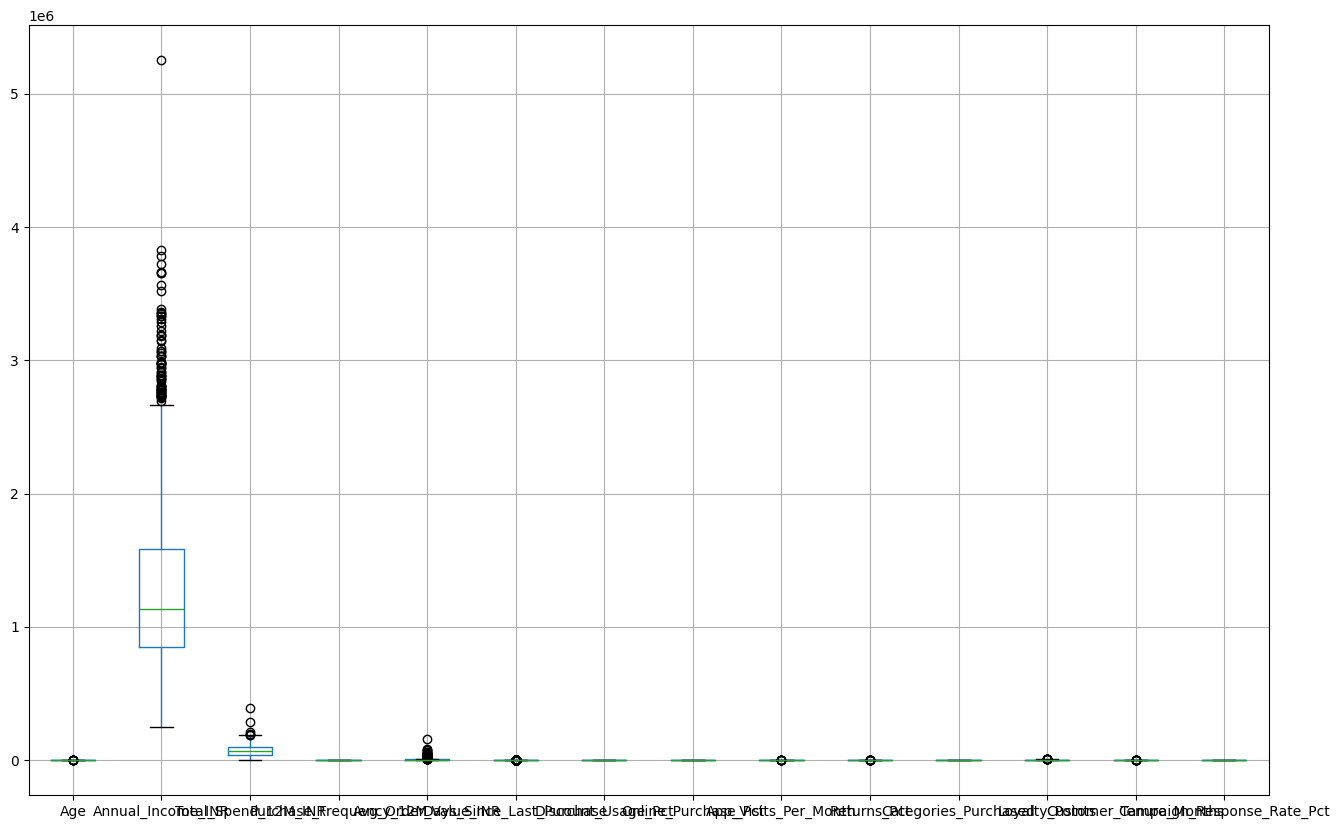

In [11]:
# EDA - Exploratory Data Analysis
plt.figure(figsize=(16,10))
df_data.boxplot()
plt.show()

                                 min        max
Age                             18.0       75.0
Annual_Income_INR           250000.0  5251946.0
Total_Spend_12M_INR           3000.0   388665.0
Purchase_Frequency_12M           1.0       42.0
Avg_Order_Value_INR            300.0   158008.0
Days_Since_Last_Purchase         1.0      365.0
Discount_Usage_Pct               0.0      100.0
Online_Purchase_Pct              0.0      100.0
App_Visits_Per_Month             0.0       56.0
Returns_Pct                      0.0       26.4
Categories_Purchased             1.0       12.0
Loyalty_Points                   0.0     9658.0
Customer_Tenure_Months           1.0      120.0
Campaign_Response_Rate_Pct       0.0      100.0


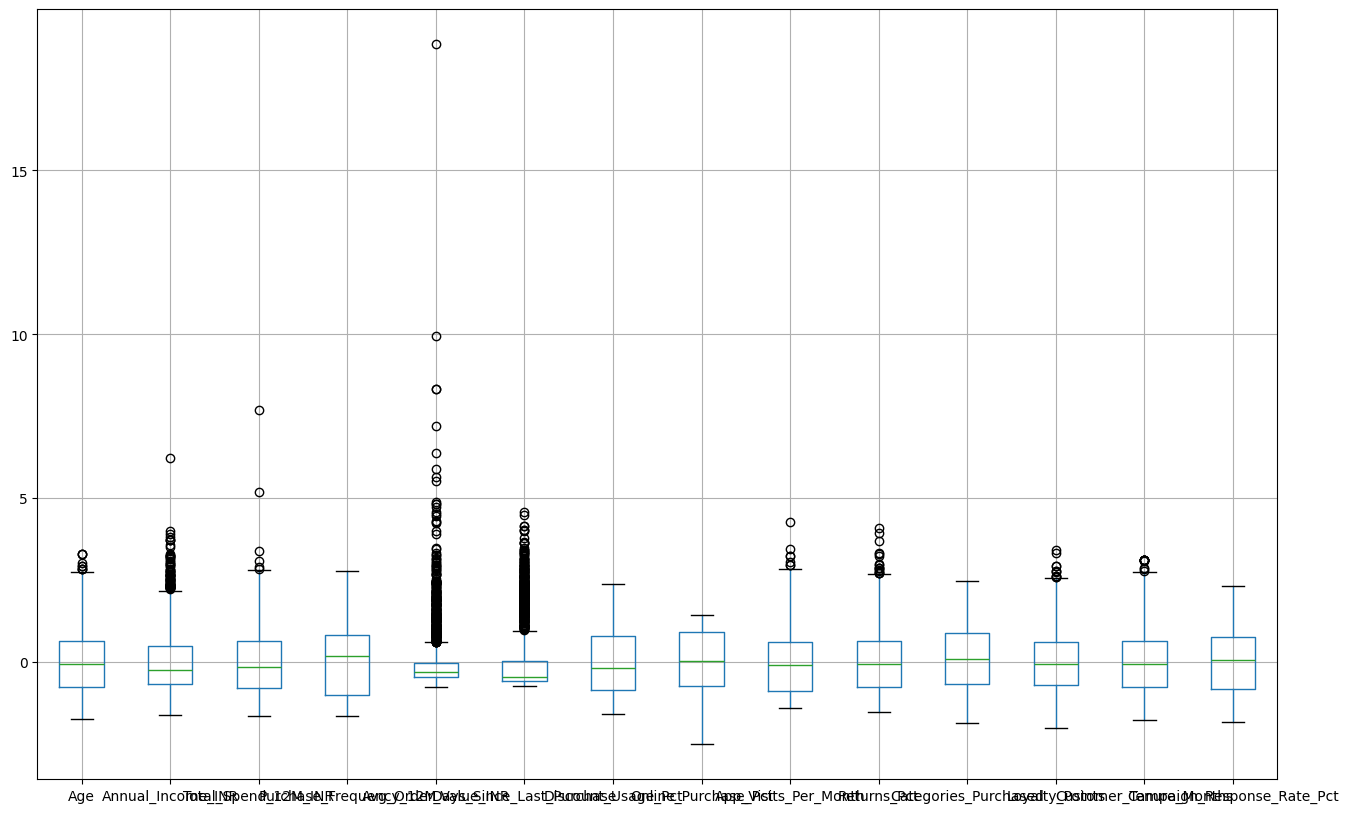

In [20]:
# Boxplot tells us why scaling is important
print(df_data.agg(['min','max']).T)

#using standard scaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_data)

#dataframe
df_data_scaled = pd.DataFrame(data_scaled, columns=df_data.columns, index=df_data.index)

plt.figure(figsize=(16,10))
df_data_scaled.boxplot()
plt.show()

In [22]:
# KMeans Algorithm

kmeans = KMeans(n_clusters=3, random_state=1, n_init=20)
labels = kmeans.fit_predict(data_scaled)
print(labels)  # output labels saying which group they belong to


[2 2 0 ... 1 2 2]


In [27]:
# What is the best number of k? Elbow method
inertia = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=20)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
    print(kmeans.inertia_)

print("Inertia:\n")
for k, score in zip(range(2,15),inertia):
    print(f"K = {k} Inertia = {score:.2f}")


20865.170982059186
16108.384910102475
13722.837424643974
11966.581751049649
11535.3053709652
11209.230660333935
10778.53609707117
10544.392688146425
10313.833576543595
10079.286723386294
9902.115997448507
9727.130759330019
9595.994126139596
Inertia:

K = 2 Inertia = 20865.17
K = 3 Inertia = 16108.38
K = 4 Inertia = 13722.84
K = 5 Inertia = 11966.58
K = 6 Inertia = 11535.31
K = 7 Inertia = 11209.23
K = 8 Inertia = 10778.54
K = 9 Inertia = 10544.39
K = 10 Inertia = 10313.83
K = 11 Inertia = 10079.29
K = 12 Inertia = 9902.12
K = 13 Inertia = 9727.13
K = 14 Inertia = 9595.99


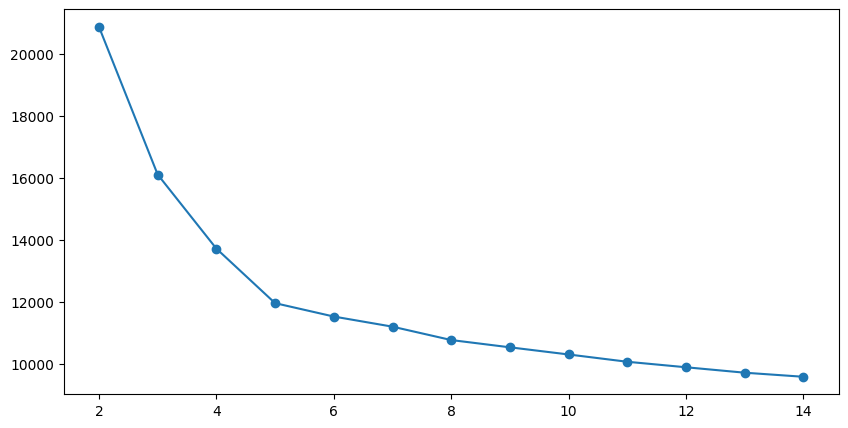

In [28]:
plt.figure(figsize=(10,5))
plt.plot(range(2,15), inertia,marker="o")
plt.show()

Sillhouette Score: It evaluates how well a customer fits within its cluster compared with neighboring clusters
its between -1 to 1  (negative means incorrectly assigned) - closer to 1 means well separated


In [29]:
silhouette_scores = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=20)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled,labels)
    silhouette_scores.append(score)

print("Inertia:\n")
for k, score in zip(range(2,15),silhouette_scores):
    print(f"K = {k} Inertia = {score:.2f}")


Inertia:

K = 2 Inertia = 0.28
K = 3 Inertia = 0.29
K = 4 Inertia = 0.29
K = 5 Inertia = 0.27
K = 6 Inertia = 0.27
K = 7 Inertia = 0.20
K = 8 Inertia = 0.20
K = 9 Inertia = 0.17
K = 10 Inertia = 0.13
K = 11 Inertia = 0.13
K = 12 Inertia = 0.13
K = 13 Inertia = 0.11
K = 14 Inertia = 0.10


In [36]:
# lets select k=4 as the best number of centers
kmeans = KMeans(n_clusters=4, random_state=1, n_init=20)
labels = kmeans.fit_predict(data_scaled)
df['Cluster'] = labels

print(df.head())

  Customer_ID  Age  Gender       City Signup_Date  Annual_Income_INR  \
0   CUST01861   39    Male    Chennai  2023-08-29          1180004.0   
1   CUST00354   18    Male       Pune  2023-06-25          1620808.0   
2   CUST01334   59    Male      Delhi  2022-02-09           875248.0   
3   CUST00906   35  Female    Chennai  2026-01-20           870223.0   
4   CUST01290   36    Male  Bengaluru  2023-11-29          1183226.0   

   Total_Spend_12M_INR  Purchase_Frequency_12M  Avg_Order_Value_INR  \
0              78897.0                      15               7607.0   
1              60324.0                      14               4773.0   
2              46379.0                       6               7461.0   
3              51190.0                      18               2653.0   
4              78450.0                      18               4492.0   

   Days_Since_Last_Purchase  Discount_Usage_Pct  Online_Purchase_Pct  \
0                         5                13.3                 88.2

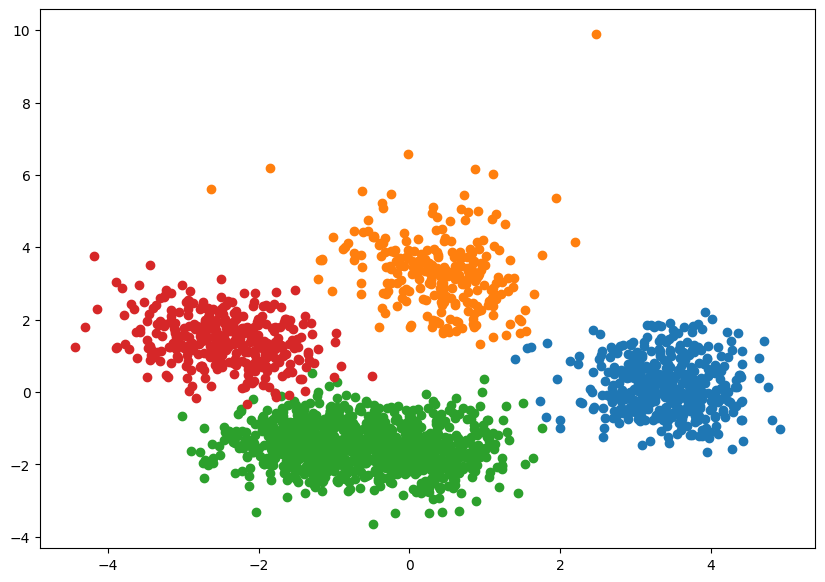

In [37]:
# Plot the clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled)

#create the dataframe
pca_df = pd.DataFrame({
    "PC1":X_pca[:,0],
    "PC2":X_pca[:,1],
    "Cluster":labels
})

plt.figure(figsize=(10,7))
for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'],label=f"Cluster {cluster}")

plt.show()

<h3>CLUSTERING TECHNIQUE 2: Heirarchical Clustering</h3>


In [43]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


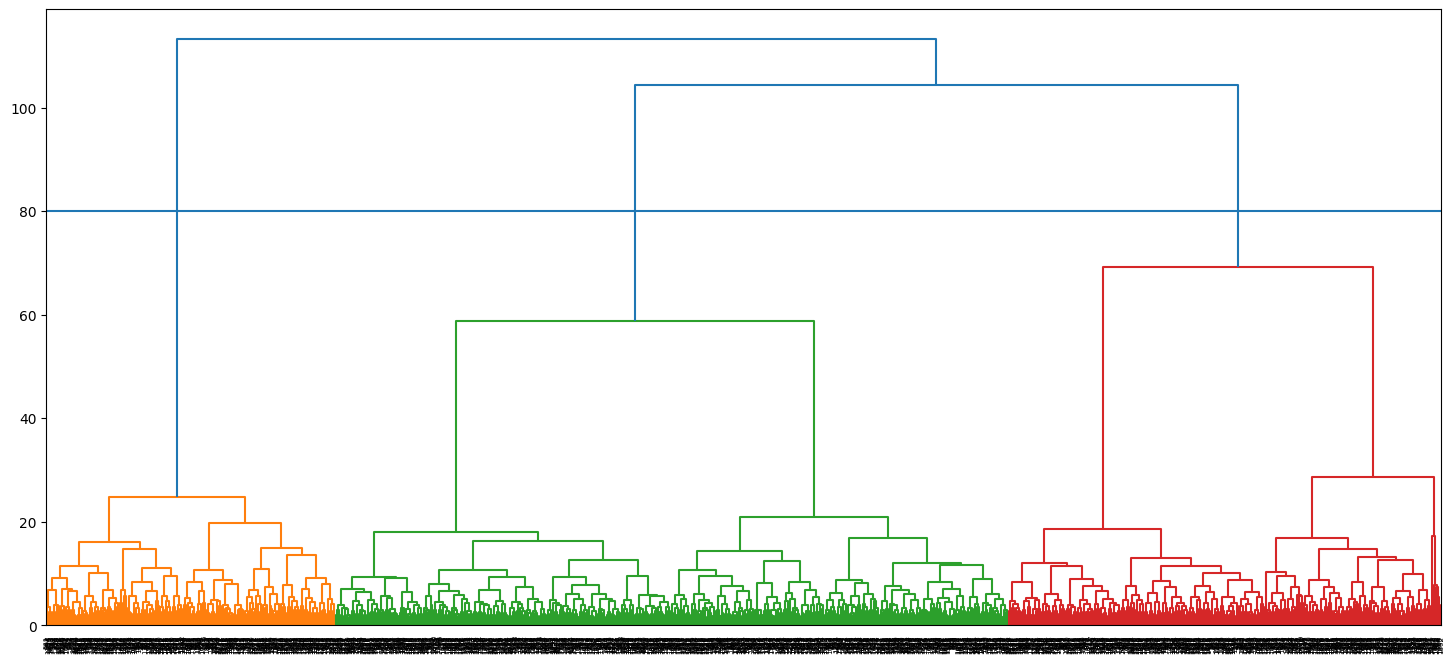

In [46]:
# data_scaled
#linkage matrix
z = linkage(data_scaled, method="ward")

#plot dendrogram
plt.figure(figsize=(18,8))
dendrogram(z)
plt.axhline(y=80)
plt.show()